<a href="https://colab.research.google.com/github/tuantrinh31251023080-bot/-me/blob/main/BTvenhaT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import folium
vitri_ueh = [10.761190211482399, 106.66829362184481]
m = folium.Map(location=vitri_ueh, zoom_start=15)
folium.Marker(
    vitri_ueh,
    popup="Đại học Kinh tế TP. Hồ Chí Minh (UEH) - Cơ sở B",
    icon=folium.Icon(color="red")
).add_to(m)
# Một vài địa điểm
folium.Marker([10.770838285016678, 106.66994425253064], popup="Vạn Hạnh Mall").add_to(m)
folium.Marker([10.751336865968156, 106.65125897369474], popup="Bến xe Chợ Lớn").add_to(m)
folium.Marker([10.757959451853642, 106.65955601020191], popup="Bệnh viện Chợ Rẫy").add_to(m)
folium.Marker([10.760677554654714, 106.67191612184475], popup="Kí túc xá UEH-Nguyễn Chí Thanh").add_to(m)
folium.Marker([10.769362354250104, 106.67404035493028], popup="UBND Phường 10, Quận 10").add_to(m)
m

In [ ]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
import time
center_coords = (10.761348313811009, 106.66837945253054)  # UEH Quận 10
geolocator = Nominatim(user_agent="geo_app", timeout=10)
addresses = [
    "Vạn Hạnh Mall, Ho Chi Minh City, Vietnam",
    "Cho Ray Hospital, Ho Chi Minh City, Vietnam",
    "Nha hat Hoa Binh, 3 Thang 2, Ho Chi Minh City, Vietnam",
    "HCMC University of Technology, Vietnam",
    "An Dong Market, Ho Chi Minh City, Vietnam",
    "Cho Lon Bus Station, Ho Chi Minh City, Vietnam",
    "Vincom Center Dong Khoi, Ho Chi Minh City, Vietnam",
    "Ben Thanh Market, Ho Chi Minh City"
    "Phu Tho Stadium, Ho Chi Minh City, Vietnam",
    "Tan Son Nhat International Airport, Ho Chi Minh City, Vietnam"
]
locations = []
for addr in addresses:
    loc = geolocator.geocode(addr)
    if loc is not None:
        coords = (loc.latitude, loc.longitude)
        distance = geodesic(center_coords, coords).km
        locations.append({
            "name": addr,
            "coords": coords,
            "distance": round(distance, 2)
        })
    time.sleep(1)
m = folium.Map(location=center_coords, zoom_start=13)
folium.Marker(
    center_coords,
    popup="UEH cơ sở B",
    icon=folium.Icon(color="red")
).add_to(m)
for loc in locations:
    folium.Marker(
        loc["coords"],
        popup=f"{loc['name']}<br>Khoảng cách: {loc['distance']} km",
        icon=folium.Icon(color="blue")
    ).add_to(m)
    folium.PolyLine(
        [center_coords, loc["coords"]],
        color="green",
        weight=2
    ).add_to(m)
m

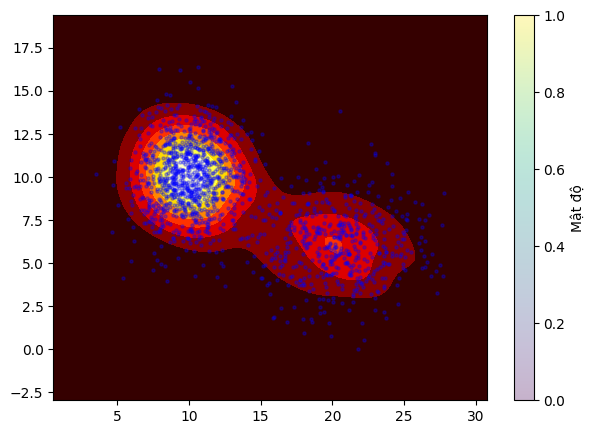

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
np.random.seed(42)
#giả lập số liệu
x = np.r_[np.random.normal(10,2,1000),
          np.random.normal(20,3,500)]
y = np.r_[np.random.normal(10,2,1000),
          np.random.normal(6,2,500)]
xi, yi = np.mgrid[x.min()-3:x.max()+3:200j,
                  y.min()-3:y.max()+3:200j]
zi = gaussian_kde(np.vstack([x,y]))(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
plt.figure(figsize=(7,5))
plt.contourf(xi, yi, zi, cmap="hot")
plt.scatter(x, y, s=5, c="blue", alpha=0.3)
plt.colorbar(label="Mật độ")
plt.show()

In [2]:
!pip install geopandas --quiet

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
np.random.seed(42)
world["value"] = np.random.randint(10, 1000, len(world))
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
world.plot(
    column="value",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)
ax.set_title("🌍 Bản đồ Choropleth: Phân bố giá trị theo khu vực (giả lập)", fontsize=14)
ax.set_axis_off()
plt.show()

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

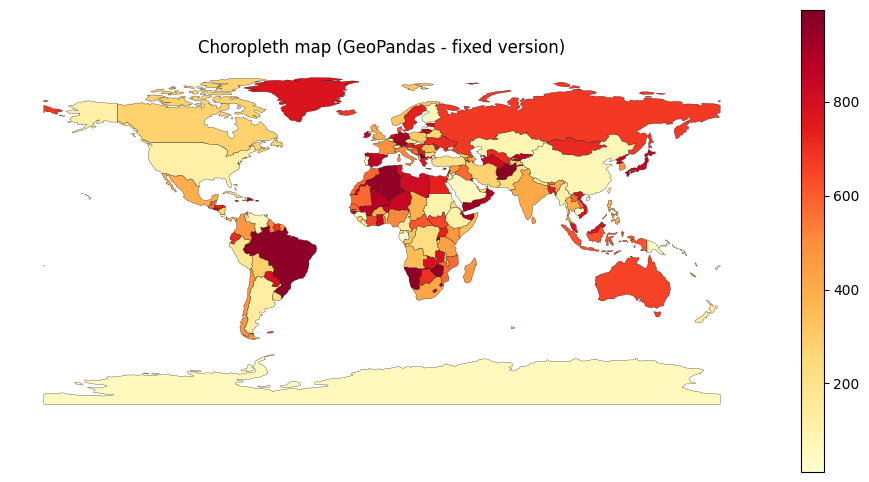

In [ ]:
!pip install geopandas --quiet

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
np.random.seed(42)
world["value"] = np.random.randint(10, 1000, len(world))
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
world.plot(
    column="value",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)
ax.set_title("Choropleth map (GeoPandas - fixed version)")
ax.set_axis_off()
plt.show()
#Bản đồ choropleth giúp nhà quản lí nhìn nhanh được sự phân hóa không gian của một chỉ số (doanh thu, dân số, đơn hàng,...). Các khu vực có màu đậm thể hiện giá trị cao thường là điểm trọng tâm cần ưu tiên đầu tư hạ tầng, nhân sự, logistic hoặc chăm sóc khách hàng để tối đa hóa hiệu quả khai thác.
#Ngược lại các khu vực màu nhạt cho thấy tiềm năng chưa được khai thác hoặc nhu cầu thấp, từ đó giúp doanh nghiệp cân nhắc chiến lược mở rộng thị trường, tối ưu chi phí hoặc điều chỉnh mức độ đầu tư.
#Tổng thể, bản đồ hỗ trợ ra quyết định phân bổ nguồn lực theo không gian một cách trực quan và ít chênh lệch hơn so với số liệu thuần.

In [ ]:
!pip install folium geopy --quiet
import folium, numpy as np
from geopy.distance import geodesic

# 1. Trung tâm (Q1)
center = (10.7769, 106.7009)

# 2. Tạo bản đồ + vòng bán kính
m = folium.Map(location=center, zoom_start=12)
radii = [3, 5, 10]  # km
colors = ["green", "orange", "red"]

for r, c in zip(radii, colors):
    folium.Circle(center, r*1000, color=c, fill=True, fill_opacity=0.2).add_to(m)

# 3. Giả lập khách hàng
np.random.seed(42)
customers = [(center[0]+np.random.uniform(-0.1,0.1),
              center[1]+np.random.uniform(-0.1,0.1)) for _ in range(200)]

# 4. Phân vùng khách hàng
zones = {"<3km":0, "3-5km":0, "5-10km":0, ">10km":0}

for lat, lon in customers:
    d = geodesic(center, (lat, lon)).km
    if d <= 3: zones["<3km"] += 1
    elif d <= 5: zones["3-5km"] += 1
    elif d <= 10: zones["5-10km"] += 1
    else: zones[">10km"] += 1

    folium.CircleMarker([lat, lon], radius=3, color="blue", fill=True).add_to(m)

# 5. Tính tỷ lệ (%)
total = len(customers)
for k in zones:
    zones[k] = round(zones[k]/total*100, 1)

print("Phân bố khách hàng (%):", zones)

m

Phân bố khách hàng (%): {'<3km': 4.0, '3-5km': 10.0, '5-10km': 51.5, '>10km': 34.5}


In [3]:

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
fig, ax = ox.plot_graph(
    G,
    node_size=10,
    edge_linewidth=0.8,
    bgcolor="white",
    show=True,
    close=False
)
num_nodes = len(G.nodes)
num_edges = len(G.edges)
edge_lengths = [
    data.get("length", 0)
    for u, v, k, data in G.edges(keys=True, data=True)
]
total_length = sum(edge_lengths)
avg_length = total_length / len(edge_lengths)
gdf = ox.geocode_to_gdf(place_name)
gdf_proj = ox.projection.project_gdf(gdf)
area = gdf_proj.geometry.area.iloc[0]
density = total_length / area
avg_degree = sum(dict(G.degree()).values()) / num_nodes
print("=== PHÂN TÍCH MẠNG GIAO THÔNG ===")
print(f"Khu vực: {place_name}")
print(f"Số nút giao: {num_nodes}")
print(f"Số đoạn đường: {num_edges}")
print(f"Tổng chiều dài đường: {total_length:.2f} m")
print(f"Chiều dài trung bình: {avg_length:.2f} m")
print(f"Mật độ mạng: {density:.8f} m/m²")
print(f"Bậc trung bình nút: {avg_degree:.2f}")

ModuleNotFoundError: No module named 'osmnx'

In [ ]:
# !pip install osmnx networkx matplotlib geopandas


In [4]:
!pip install osmnx networkx matplotlib geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 6.8 MB/s eta 0:00:00


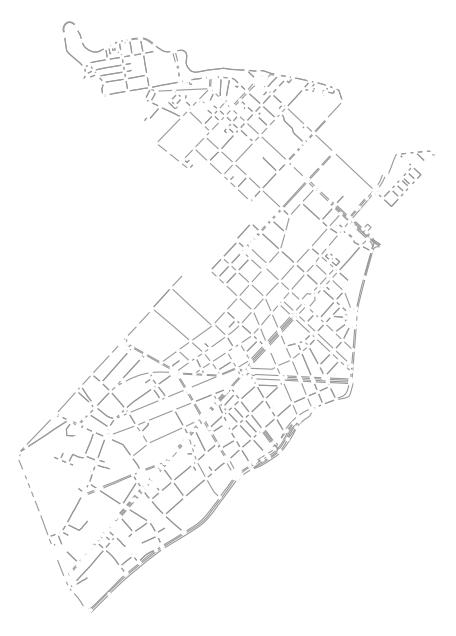

=== PHÂN TÍCH MẠNG GIAO THÔNG ===
Khu vực: District 1, Ho Chi Minh City, Vietnam
Số nút giao: 989
Số đoạn đường: 2090
Tổng chiều dài đường: 165169.72 m
Chiều dài trung bình: 79.03 m
Mật độ mạng: 0.02144989 m/m²
Bậc trung bình nút: 4.23


In [5]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
fig, ax = ox.plot_graph(
    G,
    node_size=10,
    edge_linewidth=0.8,
    bgcolor="white",
    show=True,
    close=False
)
num_nodes = len(G.nodes)
num_edges = len(G.edges)
edge_lengths = [
    data.get("length", 0)
    for u, v, k, data in G.edges(keys=True, data=True)
]
total_length = sum(edge_lengths)
avg_length = total_length / len(edge_lengths)
gdf = ox.geocode_to_gdf(place_name)
gdf_proj = ox.projection.project_gdf(gdf)
area = gdf_proj.geometry.area.iloc[0]
density = total_length / area
avg_degree = sum(dict(G.degree()).values()) / num_nodes
print("=== PHÂN TÍCH MẠNG GIAO THÔNG ===")
print(f"Khu vực: {place_name}")
print(f"Số nút giao: {num_nodes}")
print(f"Số đoạn đường: {num_edges}")
print(f"Tổng chiều dài đường: {total_length:.2f} m")
print(f"Chiều dài trung bình: {avg_length:.2f} m")
print(f"Mật độ mạng: {density:.8f} m/m²")
print(f"Bậc trung bình nút: {avg_degree:.2f}")

In [6]:

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import time
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")
start_point = (10.7798, 106.6992)
end_point   = (10.7720, 106.6983)
start_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
end_node   = ox.distance.nearest_nodes(G, end_point[1], end_point[0])
t1 = time.time()
route_dijkstra = nx.shortest_path(G, start_node, end_node, weight="length")
time_dijkstra = time.time() - t1
length_dijkstra = nx.shortest_path_length(G, start_node, end_node, weight="length")
def heuristic(u, v):
    x1 = G.nodes[u]['x']
    y1 = G.nodes[u]['y']
    x2 = G.nodes[v]['x']
    y2 = G.nodes[v]['y']
    return ((x1 - x2)**2 + (y1 - y2)**2) ** 0.5
t2 = time.time()
route_astar = nx.astar_path(G, start_node, end_node,
                           heuristic=heuristic,
                           weight="length")
time_astar = time.time() - t2
length_astar = nx.astar_path_length(G, start_node, end_node,
                                    heuristic=heuristic,
                                    weight="length")
fig, ax = ox.plot_graph(G, show=False, close=False,
                        node_size=0, edge_color="gray")
ox.plot_graph_route(G, route_dijkstra,
                    route_color="red",
                    route_linewidth=4,
                    ax=ax,
                    show=False)
ox.plot_graph_route(G, route_astar,
                    route_color="blue",
                    route_linewidth=4,
                    ax=ax,
                    show=True)
print("=== KẾT QUẢ ===")
print("Dijkstra:")
print("  Độ dài:", round(length_dijkstra, 2), "m")
print("  Thời gian:", round(time_dijkstra, 6), "s")
print("A*:")
print("  Độ dài:", round(length_astar, 2), "m")
print("  Thời gian:", round(time_astar, 6), "s")

=== KẾT QUẢ ===
Dijkstra:
  Độ dài: 1185.13 m
  Thời gian: 0.001303 s
A*:
  Độ dài: 1185.13 m
  Thời gian: 0.0014 s


In [8]:

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
place = "Vạn Hạnh Mall, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")
nodes = list(G.nodes)
num_xe = 5
num_guest = 5
xe = np.random.choice(nodes, num_xe, replace=False)
guest = np.random.choice(nodes, num_guest, replace=False)
def distance(u, v):
    return nx.shortest_path_length(G, u, v, weight="length")
assignments = []
xe_da_dung = set()
for g in guest:
    best_xe = None
    best_dist = float("inf")
    for x in xe:
        if x in xe_da_dung:
            continue
        dist = distance(x, g)
        if dist < best_dist:
            best_dist = dist
            best_xe = x
    if best_xe is not None:
        assignments.append((best_xe, g))
        xe_da_dung.add(best_xe)
fig, ax = ox.plot_graph(G, show=False, close=False,
                        node_size=0, edge_color="gray")
for x in xe:
    ax.scatter(G.nodes[x]['x'], G.nodes[x]['y'],
               c='blue', s=60)
for g in guest:
    ax.scatter(G.nodes[g]['x'], G.nodes[g]['y'],
               c='red', s=60)
for x, g in assignments:
    route = nx.shortest_path(G, x, g, weight="length")
    ox.plot_graph_route(G, route,
                        route_color='yellow',
                        route_linewidth=3,
                        ax=ax,
                        show=False,
                        close=False)
plt.show()
print("=== GHÉP XE - KHÁCH (VẠN HẠNH MALL) ===")
for i, (x, g) in enumerate(assignments):
    dist = nx.shortest_path_length(G, x, g, weight="length")
    print(f"Guest {i+1} ← Xe {i+1} | Khoảng cách: {round(dist,2)} m")

ValueError: Found no graph nodes within the requested polygon.

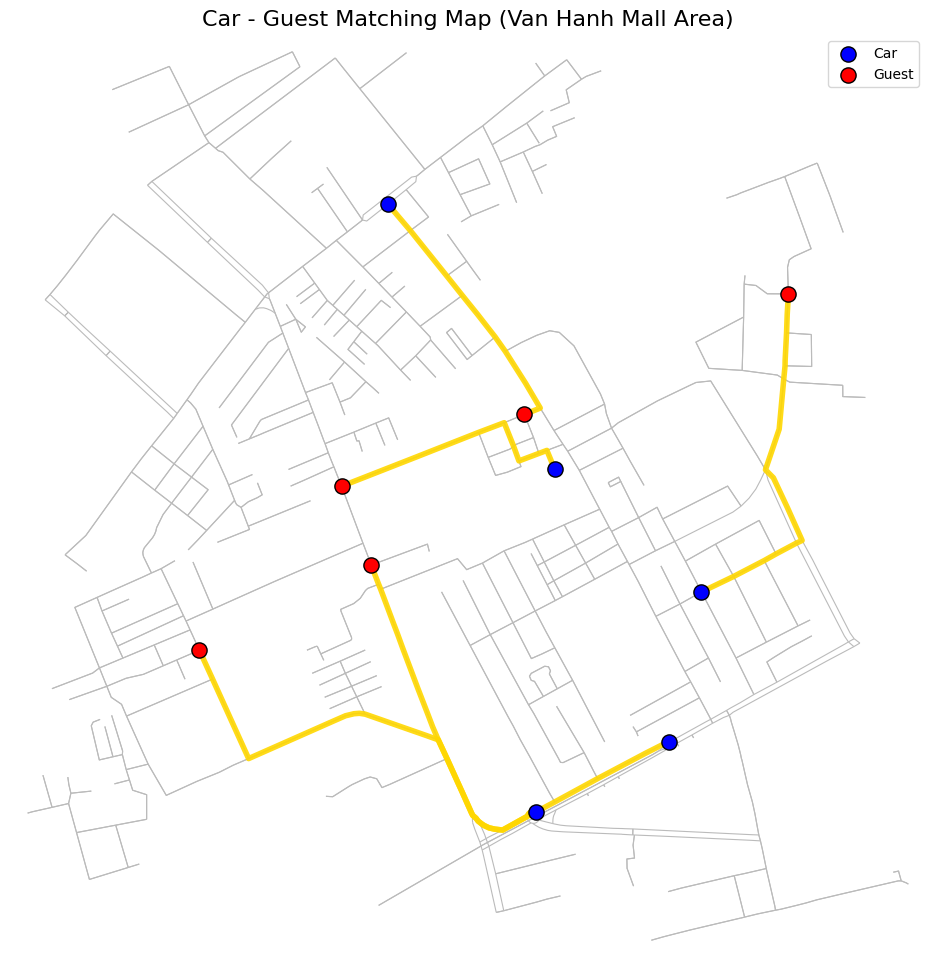

 GHÉP XE - KHÁCH 
Guest 1 ← Xe 1 | 468.19 m
Guest 2 ← Xe 2 | 479.4 m
Guest 3 ← Xe 3 | 606.42 m
Guest 4 ← Xe 4 | 1109.74 m
Guest 5 ← Xe 5 | 655.45 m


In [10]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
#BẢN ĐỒ VẠN HẠNH MALL
center_point = (10.7732, 106.6669)
G = ox.graph_from_point(center_point, dist=800, network_type="drive")
largest_cc = max(nx.strongly_connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
#XE VÀ KHÁCH
nodes = list(G.nodes)
num_xe = 5
num_guest = 5
xe = np.random.choice(nodes, num_xe, replace=False)
guest = np.random.choice(nodes, num_guest, replace=False)
def distance(u, v):
    return nx.shortest_path_length(G, u, v, weight="length")
assignments = []
xe_used = set()
for g in guest:
    best_xe = None
    best_dist = float("inf")
    for x in xe:
        if x in xe_used:
            continue
        dist = distance(x, g)
        if dist < best_dist:
            best_dist = dist
            best_xe = x
    if best_xe is not None:
        assignments.append((best_xe, g))
        xe_used.add(best_xe)
fig, ax = ox.plot_graph(
    G,
    bgcolor="white",
    node_size=0,
    edge_color="#BBBBBB",
    edge_linewidth=0.8,
    show=False,
    close=False,
    figsize=(12,12)
)
for x in xe:
    ax.scatter(
        G.nodes[x]['x'],
        G.nodes[x]['y'],
        c="blue",
        s=120,
        edgecolors="black",
        zorder=5,
        label="Car"
    )
for g in guest:
    ax.scatter(
        G.nodes[g]['x'],
        G.nodes[g]['y'],
        c="red",
        s=120,
        edgecolors="black",
        zorder=5,
        label="Guest"
    )
for x, g in assignments:
    route = nx.shortest_path(G, x, g, weight="length")
    ox.plot_graph_route(
        G,
        route,
        route_color="gold",
        route_linewidth=4,
        route_alpha=0.9,
        ax=ax,
        show=False,
        close=False
    )
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper right")
plt.title("Car - Guest Matching Map (Van Hanh Mall Area)", fontsize=16)
plt.show()
print(" GHÉP XE - KHÁCH ")
for i, (x, g) in enumerate(assignments):
    dist = nx.shortest_path_length(G, x, g, weight="length")
    print(f"Guest {i+1} ← Xe {i+1} | {round(dist,2)} m")

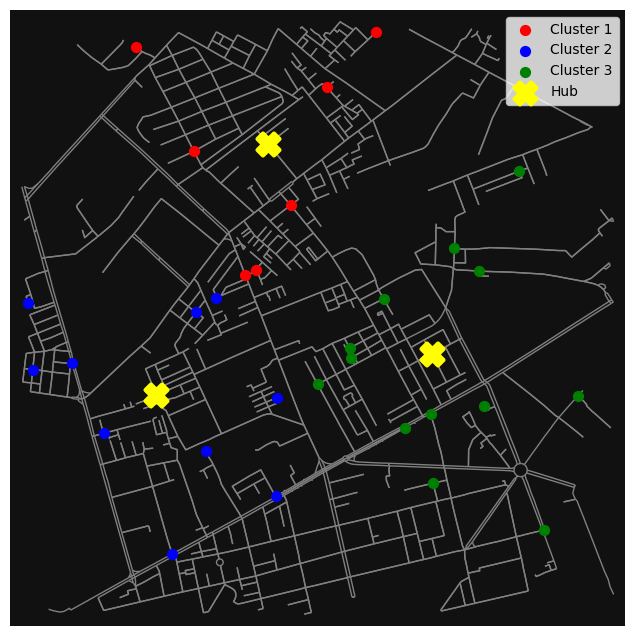

VỊ TRÍ TRẠM 
Trạm 1: (682058.11, 1192115.10)
Trạm 2: (681604.03, 1191096.80)
Trạm 3: (682722.72, 1191263.30)


In [11]:

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
center = (10.7732, 106.6669)
G = ox.graph_from_point(center, dist=1200, network_type="drive")
G = ox.project_graph(G)
nodes = list(G.nodes)
customer_nodes = np.random.choice(nodes, 30, replace=False)
X = np.array([
    (G.nodes[n]['x'], G.nodes[n]['y'])
    for n in customer_nodes
])
k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_
hub_nodes = []
for c in centers:
    hub = ox.distance.nearest_nodes(G, c[0], c[1])
    hub_nodes.append(hub)
fig, ax = ox.plot_graph(G, show=False, close=False,
                        node_size=0, edge_color="gray")
colors = ["red", "blue", "green"]
for i in range(k):
    pts = X[labels == i]
    ax.scatter(pts[:,0], pts[:,1],
               c=colors[i], s=50, label=f"Cluster {i+1}")
#TRẠM
for i, h in enumerate(hub_nodes):
    x = G.nodes[h]['x']
    y = G.nodes[h]['y']
    ax.scatter(x, y,
               c="yellow",
               s=250,
               marker="X",
               linewidths=3,
               label="Hub" if i == 0 else "")

plt.legend()
plt.show()
print("VỊ TRÍ TRẠM ")
for i, h in enumerate(hub_nodes):
    x = G.nodes[h]['x']
    y = G.nodes[h]['y']
    print(f"Trạm {i+1}: ({x:.2f}, {y:.2f})")

In [12]:
import networkx as nx
import numpy as np
import folium
from folium.plugins import HeatMap
np.random.seed(42)
G = nx.grid_2d_graph(10, 10)
pos = {(x, y): (106.6 + x * 0.01, 10.7 + y * 0.01) for x, y in G.nodes()}
risk = {}
for node in G.nodes():
    x, y = node
    center_pressure = np.exp(-((x - 5) ** 2 + (y - 5) ** 2) / 10)
    noise = np.random.rand() * 0.5
    risk[node] = 0.6 * center_pressure + 0.4 * noise
for u, v in G.edges():
    G[u][v]["weight"] = 1 + (risk[u] + risk[v]) / 2 * 5
#Giả sử điểm bắt đầu đi và điểm đến
start = (0, 0)
end = (9, 9)
#Tìm đường đi nhanh nhất
path = nx.shortest_path(G, start, end, weight="weight")
m = folium.Map(location=[10.77, 106.69], zoom_start=13)
heat_data = [
    [pos[node][1], pos[node][0], risk[node]]
    for node in G.nodes()
]

HeatMap(heat_data, radius=12).add_to(m)

for u, v in G.edges():
    folium.PolyLine(
        locations=[(pos[u][1], pos[u][0]), (pos[v][1], pos[v][0])],
        color="gray",
        weight=1,
        opacity=0.4
    ).add_to(m)
route = [(pos[n][1], pos[n][0]) for n in path]
folium.PolyLine(
    route,
    color="red",
    weight=5,
    tooltip="Tuyến đề xuất tránh tắc nghẽn"
).add_to(m)
folium.Marker(
    location=(pos[start][1], pos[start][0]),
    popup="Start",
    icon=folium.Icon(color="green")
).add_to(m)
folium.Marker(
    location=(pos[end][1], pos[end][0]),
    popup="End",
    icon=folium.Icon(color="blue")
).add_to(m)
print("Đã tạo bản đồ: traffic_risk_map.html")
m

Đã tạo bản đồ: traffic_risk_map.html


In [13]:
!pip install folium --quiet

Sample data:
         lat         lon  hour  day_of_week     demand
0  10.786834  106.716467    21            0  13.889838
1  10.774135  106.689876     8            3  30.654505
2  10.789854  106.684536     6            1  32.952694
3  10.807361  106.700833    20            2   8.046812
4  10.772217  106.697496    23            1  20.576004

Model RMSE: 3.333701789006847


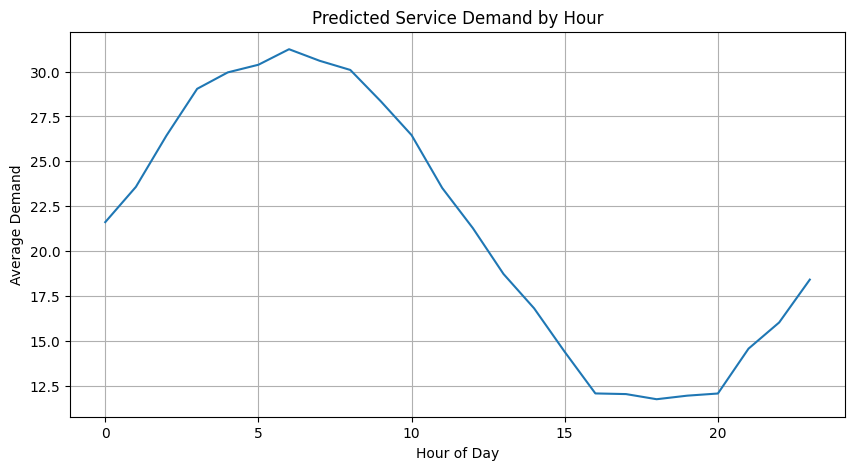

/tmp/ipykernel_1940/109982048.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_demand = data.groupby("region")["predicted_demand"].mean()



Demand by region:
region
South        20.733164
Mid-South    20.676482
Mid-North    20.736836
North        21.705378
Name: predicted_demand, dtype: float64


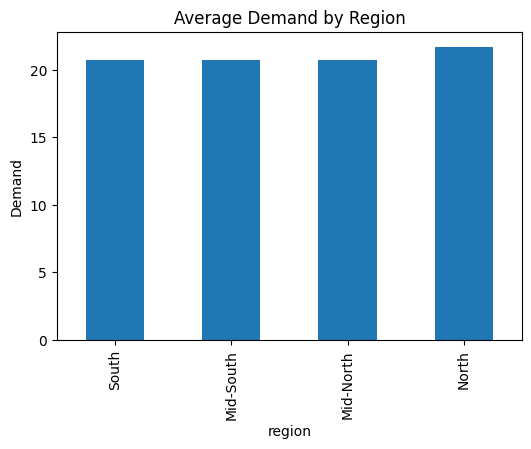


Service Demand Heatmap:


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import folium
from folium.plugins import HeatMap
from IPython.display import display
np.random.seed(42)
n_samples = 1500
# Tọa độ TPHCM
lat_center = 10.7769
lon_center = 106.7009
data = pd.DataFrame({
    "lat": lat_center + np.random.normal(0, 0.02, n_samples),
    "lon": lon_center + np.random.normal(0, 0.02, n_samples),
    "hour": np.random.randint(0, 24, n_samples),
    "day_of_week": np.random.randint(0, 7, n_samples)
})

#Mô phỏng nhu cầu
data["demand"] = (
    20
    + 10 * np.sin(data["hour"] / 24 * 2 * np.pi)
    + 5 * (data["day_of_week"] >= 5)
    + np.random.normal(0, 3, n_samples)
)

data["demand"] = data["demand"].clip(0)

print("Sample data:")
print(data.head())

data["is_weekend"] = data["day_of_week"].isin([5,6]).astype(int)

X = data[["lat","lon","hour","day_of_week","is_weekend"]]
y = data["demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=120,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print("\nModel RMSE:", rmse)

data["predicted_demand"] = model.predict(X)

hourly_demand = data.groupby("hour")["predicted_demand"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_demand)
plt.title("Predicted Service Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.grid(True)
plt.show()
# Phân tích khu vực
data["region"] = pd.qcut(
    data["lat"],
    4,
    labels=["South","Mid-South","Mid-North","North"]
)
region_demand = data.groupby("region")["predicted_demand"].mean()
print("\nDemand by region:")
print(region_demand)
plt.figure(figsize=(6,4))
region_demand.plot(kind="bar")
plt.title("Average Demand by Region")
plt.ylabel("Demand")
plt.show()
m = folium.Map(
    location=[lat_center, lon_center],
    zoom_start=12
)

heat_data = [
    [row["lat"], row["lon"], row["predicted_demand"]]
    for _, row in data.iterrows()
]

HeatMap(
    heat_data,
    radius=10
).add_to(m)

print("\nService Demand Heatmap:")
m


Tổng khoảng cách ngẫu nhiên: 237.18988805375744
Tổng khoảng cách tối ưu 136.15788643351485
Cải tiến (%): 42.59540845069432


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


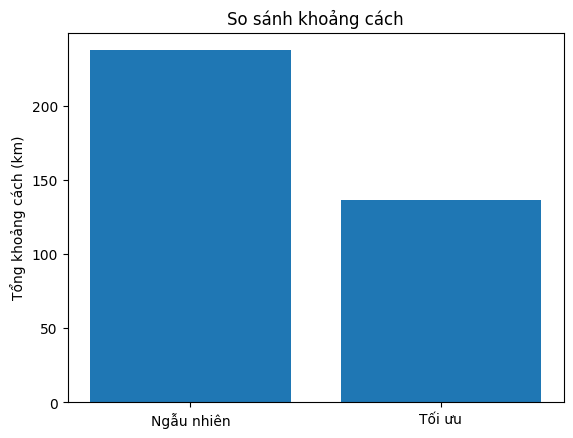

In [17]:

import numpy as np
import pandas as pd
import folium
import random
import matplotlib.pyplot as plt
from math import radians, cos, sin, sqrt, atan2
from IPython.display import display

def distance(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c


np.random.seed(42)

lat_center = 10.7769
lon_center = 106.7009

n_depots = 3
n_customers = 30
n_vehicles = 6

depots = pd.DataFrame({
    "lat": lat_center + np.random.normal(0,0.02,n_depots),
    "lon": lon_center + np.random.normal(0,0.02,n_depots)
})

customers = pd.DataFrame({
    "lat": lat_center + np.random.normal(0,0.04,n_customers),
    "lon": lon_center + np.random.normal(0,0.04,n_customers)
})

assignments = []

for i,c in customers.iterrows():

    best_depot = None
    best_dist = 1e9

    for j,d in depots.iterrows():

        dist = distance(c.lat,c.lon,d.lat,d.lon)

        if dist < best_dist:
            best_dist = dist
            best_depot = j

    assignments.append(best_depot)

customers["depot"] = assignments


def random_routes():

    routes = []
    total_distance = 0

    shuffled = customers.sample(frac=1).reset_index()

    chunks = np.array_split(shuffled, n_vehicles)

    for vehicle,chunk in enumerate(chunks):

        depot_id = chunk.iloc[0]["depot"]
        depot = depots.loc[depot_id]

        prev_lat = depot.lat
        prev_lon = depot.lon

        route = [(prev_lat,prev_lon)]

        for _,row in chunk.iterrows():

            dist = distance(prev_lat,prev_lon,row.lat,row.lon)
            total_distance += dist

            prev_lat = row.lat
            prev_lon = row.lon

            route.append((prev_lat,prev_lon))

        total_distance += distance(prev_lat,prev_lon,depot.lat,depot.lon)

        route.append((depot.lat,depot.lon))

        routes.append(route)

    return routes,total_distance


def nearest_neighbor():

    remaining = customers.copy()
    routes = []
    total_distance = 0

    for v in range(n_vehicles):

        if len(remaining)==0:
            break

        start = remaining.iloc[0]
        depot = depots.loc[start.depot]

        current_lat = depot.lat
        current_lon = depot.lon

        route=[(current_lat,current_lon)]

        vehicle_capacity = int(n_customers/n_vehicles)

        for _ in range(vehicle_capacity):

            if len(remaining)==0:
                break

            best=None
            best_dist=1e9
            best_idx=None

            for idx,row in remaining.iterrows():

                dist = distance(current_lat,current_lon,row.lat,row.lon)

                if dist<best_dist:
                    best=row
                    best_dist=dist
                    best_idx=idx

            total_distance += best_dist

            current_lat=best.lat
            current_lon=best.lon

            route.append((current_lat,current_lon))

            remaining=remaining.drop(best_idx)

        total_distance += distance(current_lat,current_lon,depot.lat,depot.lon)

        route.append((depot.lat,depot.lon))

        routes.append(route)

    return routes,total_distance


random_routes_result,random_distance = random_routes()
opt_routes,opt_distance = nearest_neighbor()

print("Tổng khoảng cách ngẫu nhiên:",random_distance)
print("Tổng khoảng cách tối ưu",opt_distance)

improvement = (random_distance-opt_distance)/random_distance*100

print("Cải tiến (%):",improvement)
m = folium.Map(location=[lat_center,lon_center],zoom_start=12)
for i,row in depots.iterrows():
    folium.Marker(
        [row.lat,row.lon],
        icon=folium.Icon(color="red"),
        popup=f"Depot {i}"
    ).add_to(m)

for i,row in customers.iterrows():
    folium.CircleMarker(
        [row.lat,row.lon],
        radius=4,
        color="blue",
        fill=True
    ).add_to(m)

colors=["green","purple","orange","black","pink","brown"]

for i,route in enumerate(opt_routes):

    folium.PolyLine(
        route,
        color=colors[i%len(colors)],
        weight=4,
        opacity=0.8
    ).add_to(m)

display(m)


plt.bar(
    ["Ngẫu nhiên","Tối ưu"],
    [random_distance,opt_distance]
)

plt.title("So sánh khoảng cách")
plt.ylabel("Tổng khoảng cách (km)")
plt.show()

Giải pháp ngẫu nhiên
D1 ['D1', 'C6', 'C2', 'C1', 'D1']
D2 ['D2', 'C5', 'C3', 'C4', 'D2']
Tổng khoảng cách: 51.54

Giải pháp theo phương pháp thực nghiệm
D1 ['D1', 'C1', 'C3', 'C2', 'D1']
D2 ['D2', 'C4', 'C5', 'C6', 'D2']
Tổng khoảng cách: 28.59

Cải tiến: 44.53 %


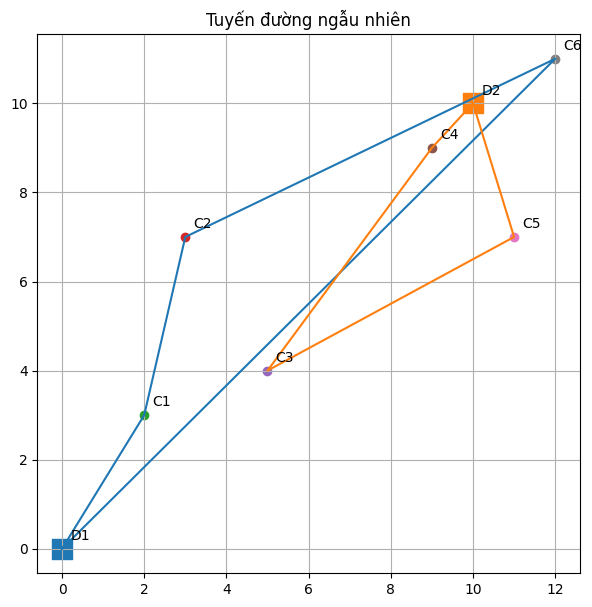

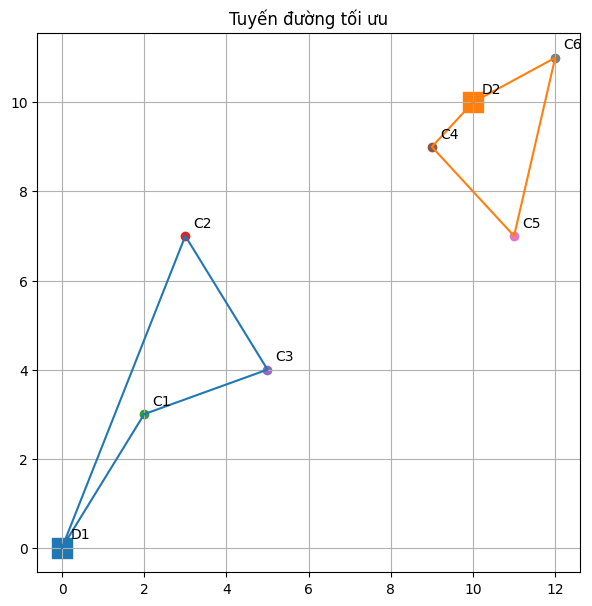

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import random

depots = {
    "D1": (0,0),
    "D2": (10,10)
}

customers = {
    "C1": (2,3),
    "C2": (3,7),
    "C3": (5,4),
    "C4": (9,9),
    "C5": (11,7),
    "C6": (12,11)
}

def distance(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def random_solution():

    cust_list = list(customers.keys())
    random.shuffle(cust_list)

    half = len(cust_list)//2

    assign = {
        "D1": cust_list[:half],
        "D2": cust_list[half:]
    }

    routes = {}
    total_dist = 0

    for depot in assign:

        route = [depot] + assign[depot] + [depot]
        routes[depot] = route

        dist = 0
        for i in range(len(route)-1):

            p1 = depots[route[i]] if route[i] in depots else customers[route[i]]
            p2 = depots[route[i+1]] if route[i+1] in depots else customers[route[i+1]]

            dist += distance(p1,p2)

        total_dist += dist

    return routes,total_dist

def cluster_customers():

    clusters = {d: [] for d in depots}

    for cname,cpos in customers.items():

        nearest = min(depots, key=lambda d: distance(cpos,depots[d]))
        clusters[nearest].append(cname)

    return clusters

def nearest_neighbor(depot,customer_list):

    depot_pos = depots[depot]
    unvisited = customer_list.copy()

    route = [depot]
    current_pos = depot_pos
    total_dist = 0

    while unvisited:

        next_customer = min(unvisited,
                            key=lambda c: distance(current_pos,customers[c]))

        total_dist += distance(current_pos,customers[next_customer])
        current_pos = customers[next_customer]

        route.append(next_customer)
        unvisited.remove(next_customer)

    total_dist += distance(current_pos,depot_pos)
    route.append(depot)

    return route,total_dist

def heuristic_solution():

    clusters = cluster_customers()

    routes = {}
    total = 0

    for depot in clusters:

        route,dist = nearest_neighbor(depot,clusters[depot])

        routes[depot] = route
        total += dist

    return routes,total

def plot_routes(routes,title):

    plt.figure(figsize=(7,7))

    for name,pos in depots.items():
        plt.scatter(pos[0],pos[1],marker='s',s=200,label=name)
        plt.text(pos[0]+0.2,pos[1]+0.2,name)

    for name,pos in customers.items():
        plt.scatter(pos[0],pos[1])
        plt.text(pos[0]+0.2,pos[1]+0.2,name)

    for depot,route in routes.items():

        coords=[]

        for node in route:

            if node in depots:
                coords.append(depots[node])
            else:
                coords.append(customers[node])

        xs=[c[0] for c in coords]
        ys=[c[1] for c in coords]

        plt.plot(xs,ys)

    plt.title(title)
    plt.grid(True)
    plt.show()

random_routes,random_dist = random_solution()
heuristic_routes,heuristic_dist = heuristic_solution()

print("Giải pháp ngẫu nhiên")
for k,v in random_routes.items():
    print(k,v)

print("Tổng khoảng cách:",round(random_dist,2))

print("\nGiải pháp theo phương pháp thực nghiệm")
for k,v in heuristic_routes.items():
    print(k,v)

print("Tổng khoảng cách:",round(heuristic_dist,2))

improve = (random_dist-heuristic_dist)/random_dist*100

print("\nCải tiến:",round(improve,2),"%")

plot_routes(random_routes,"Tuyến đường ngẫu nhiên")
plot_routes(heuristic_routes,"Tuyến đường tối ưu")

In [21]:
!pip install folium geopandas shapely

In [22]:
import folium
import geopandas as gpd
from shapely.geometry import Point, Polygon, LineString

depots = {
    "D1": (10.76,106.67),
    "D2": (10.80,106.70)
}

customers = {
    "C1": (10.77,106.66),
    "C2": (10.78,106.68),
    "C3": (10.79,106.69),
    "C4": (10.81,106.71),
    "C5": (10.82,106.69),
    "C6": (10.80,106.72)
}

region1 = Polygon([
    (106.65,10.75),
    (106.69,10.75),
    (106.69,10.79),
    (106.65,10.79)
])

region2 = Polygon([
    (106.69,10.79),
    (106.73,10.79),
    (106.73,10.83),
    (106.69,10.83)
])

regions = gpd.GeoDataFrame({
    "region":["Zone A","Zone B"],
    "orders":[120,90],
    "geometry":[region1,region2]
})

route1 = LineString([
    (106.67,10.76),
    (106.66,10.77),
    (106.68,10.78),
    (106.67,10.76)
])

route2 = LineString([
    (106.70,10.80),
    (106.71,10.81),
    (106.69,10.82),
    (106.70,10.80)
])

routes = gpd.GeoDataFrame({
    "route":["Route 1","Route 2"],
    "distance":[8,6],
    "geometry":[route1,route2]
})

m = folium.Map(location=[10.78,106.69], zoom_start=13)

region_layer = folium.FeatureGroup(name="Regions")

for _,row in regions.iterrows():

    folium.GeoJson(
        row["geometry"],
        tooltip=f'Region: {row["region"]} | Orders: {row["orders"]}'
    ).add_to(region_layer)

region_layer.add_to(m)

point_layer = folium.FeatureGroup(name="Points")

for name,(lat,lon) in depots.items():

    folium.Marker(
        location=[lat,lon],
        popup=f"Depot {name}",
        icon=folium.Icon(color="red",icon="home")
    ).add_to(point_layer)

for name,(lat,lon) in customers.items():

    folium.CircleMarker(
        location=[lat,lon],
        radius=6,
        color="blue",
        fill=True,
        popup=f"Customer {name}"
    ).add_to(point_layer)

point_layer.add_to(m)

route_layer = folium.FeatureGroup(name="Routes")

for _,row in routes.iterrows():

    coords = [(y,x) for x,y in row["geometry"].coords]

    folium.PolyLine(
        locations=coords,
        weight=4,
        tooltip=f'{row["route"]} | Distance: {row["distance"]} km'
    ).add_to(route_layer)

route_layer.add_to(m)

folium.LayerControl().add_to(m)

m

In [23]:
!pip install folium networkx

import folium
import networkx as nx
import time
from IPython.display import display, clear_output

G = nx.Graph()

nodes = {
"A":(10.76,106.66),
"B":(10.77,106.68),
"C":(10.78,106.70),
"D":(10.75,106.67),
"E":(10.76,106.69)
}

for n,pos in nodes.items():
    G.add_node(n,pos=pos)

edges=[("A","B"),("B","C"),("A","D"),("B","E"),("D","E")]

G.add_edges_from(edges)

vehicles=[
{"id":"V1","route":["A","B","C"],"step":0},
{"id":"V2","route":["D","E","B"],"step":0}
]

def draw_map():

    m = folium.Map(location=[10.77,106.68],zoom_start=14)

    for u,v in G.edges():

        p1=nodes[u]
        p2=nodes[v]

        folium.PolyLine([p1,p2],color="gray").add_to(m)

    for n,pos in nodes.items():

        folium.CircleMarker(
            pos,
            radius=5,
            color="black",
            fill=True,
            popup=n
        ).add_to(m)

    for v in vehicles:

        node=v["route"][v["step"]]
        pos=nodes[node]

        folium.Marker(
            pos,
            popup=f'Vehicle {v["id"]}',
            icon=folium.Icon(color="red",icon="car")
        ).add_to(m)

    return m

for t in range(5):

    clear_output(wait=True)

    m=draw_map()
    display(m)

    for v in vehicles:

        if v["step"] < len(v["route"])-1:
            v["step"]+=1

    time.sleep(2)

In [24]:
!pip install osmnx folium networkx

In [28]:

import osmnx as ox
import networkx as nx
import folium
import random

place = "Van Hanh Mall, District 10, Ho Chi Minh City, Vietnam"

G = ox.graph_from_address(
    place,
    dist=1500,
    network_type="drive"
)

print("So nut:", len(G.nodes))
print("So canh:", len(G.edges))

nodes = list(G.nodes)

warehouse = random.choice(nodes)

num_deliveries = 8
delivery_points = random.sample(nodes, num_deliveries)

num_vehicles = 3

vehicles = []

for i in range(num_vehicles):
    vehicle = {
        "id": i,
        "location": warehouse
    }
    vehicles.append(vehicle)

print("Danh sach xe:", vehicles)

random_route = []
current = warehouse

for point in delivery_points:

    path = nx.shortest_path(
        G,
        current,
        point,
        weight="length"
    )

    random_route.append(path)
    current = point

remaining = delivery_points.copy()
current = warehouse
optimal_routes = []

while remaining:

    nearest = min(
        remaining,
        key=lambda x: nx.shortest_path_length(
            G,
            current,
            x,
            weight="length"
        )
    )

    route = nx.shortest_path(
        G,
        current,
        nearest,
        weight="length"
    )

    optimal_routes.append(route)

    current = nearest
    remaining.remove(nearest)

def route_distance(routes):

    total = 0

    for route in routes:

        length = nx.shortest_path_length(
            G,
            route[0],
            route[-1],
            weight="length"
        )

        total += length

    return total


random_distance = route_distance(random_route)
optimal_distance = route_distance(optimal_routes)

print("Khoang cach khong toi uu:", round(random_distance/1000,2),"km")
print("Khoang cach toi uu:", round(optimal_distance/1000,2),"km")

lat = G.nodes[warehouse]["y"]
lon = G.nodes[warehouse]["x"]

m = folium.Map(
    location=[lat,lon],
    zoom_start=12
)

folium.Marker(
    location=[lat,lon],
    popup="Warehouse",
    icon=folium.Icon(color="green")
).add_to(m)

for point in delivery_points:

    lat = G.nodes[point]["y"]
    lon = G.nodes[point]["x"]

    folium.Marker(
        location=[lat,lon],
        popup="Delivery Point",
        icon=folium.Icon(color="red")
    ).add_to(m)

for route in random_route:

    coords = [
        (G.nodes[node]["y"],G.nodes[node]["x"])
        for node in route
    ]

    folium.PolyLine(
        coords,
        color="orange",
        weight=3,
        tooltip="Non Optimal Route"
    ).add_to(m)

for route in optimal_routes:

    coords = [
        (G.nodes[node]["y"],G.nodes[node]["x"])
        for node in route
    ]

    folium.PolyLine(
        coords,
        color="blue",
        weight=5,
        tooltip="Optimal Route"
    ).add_to(m)

m

InsufficientResponseError: Nominatim could not geocode query 'Van Hanh Mall, District 10, Ho Chi Minh City, Vietnam'.

In [29]:
!pip install osmnx folium networkx

import osmnx as ox
import networkx as nx
import folium
import random
#Tọa độ Vincom Đồng Khởi
center_point = (10.7797,106.7043)
# Mạng lưới đường di chuyển
G = ox.graph_from_point(
    center_point,
    dist=1200,
    network_type="drive"
)

print("Nodes:",len(G.nodes))
print("Edges:",len(G.edges))
#Tạo kho và điểm giao hàng

nodes = list(G.nodes)

warehouse = ox.distance.nearest_nodes(
    G,
    center_point[1],
    center_point[0]
)

num_deliveries = 8
delivery_points = random.sample(nodes,num_deliveries)

#TẠO XE
num_vehicles = 3
vehicles=[]
for i in range(num_vehicles):
    vehicles.append({
        "id":i,
        "color":random.choice(["red","blue","green"]),
        "location":warehouse
    })
print("Vehicles:",vehicles)
#Route không tối ưu
random_route=[]
current=warehouse
for point in delivery_points:
    path=nx.shortest_path(
        G,
        current,
        point,
        weight="length"
    )

    random_route.append(path)

    current=point
#Route tối ưu
remaining=delivery_points.copy()
current=warehouse

optimal_routes=[]

while remaining:

    nearest=min(
        remaining,
        key=lambda x: nx.shortest_path_length(
            G,
            current,
            x,
            weight="length"
        )
    )

    route=nx.shortest_path(
        G,
        current,
        nearest,
        weight="length"
    )

    optimal_routes.append(route)

    current=nearest
    remaining.remove(nearest)
#Khoảng cách
def route_distance(routes):
    total=0
    for route in routes:
        for i in range(len(route)-1):
            edge=G.get_edge_data(route[i],route[i+1])[0]
            total+=edge["length"]
    return total
random_distance=route_distance(random_route)
optimal_distance=route_distance(optimal_routes)
improvement=(random_distance-optimal_distance)/random_distance*100
print("Random route:",round(random_distance/1000,2),"km")
print("Optimal route:",round(optimal_distance/1000,2),"km")
print("Improvement:",round(improvement,1),"%")
#Tạo map
lat=G.nodes[warehouse]["y"]
lon=G.nodes[warehouse]["x"]
m=folium.Map(
    location=[lat,lon],
    zoom_start=15
)
#Kho
folium.Marker(
    [lat,lon],
    popup="Warehouse",
    icon=folium.Icon(color="green",icon="home")
).add_to(m)
#Nút giao
for point in delivery_points:
    lat=G.nodes[point]["y"]
    lon=G.nodes[point]["x"]

    folium.CircleMarker(
        [lat,lon],
        radius=6,
        color="red",
        fill=True,
        popup="Delivery"
    ).add_to(m)
#Vẽ đường route không tối ưu
for route in random_route:

    coords=[
        (G.nodes[n]["y"],G.nodes[n]["x"])
        for n in route
    ]

    folium.PolyLine(
        coords,
        color="orange",
        weight=3,
        tooltip="Non optimal"
    ).add_to(m)
#Vẽ đường route tối ưu
colors=["blue","purple","black"]
for i,route in enumerate(optimal_routes):
    coords=[
        (G.nodes[n]["y"],G.nodes[n]["x"])
        for n in route
    ]
    folium.PolyLine(
        coords,
        color=colors[i%len(colors)],
        weight=5,
        tooltip=f"Vehicle {i}"
    ).add_to(m)
m

Nodes: 525
Edges: 1101
Vehicles: [{'id': 0, 'color': 'red', 'location': 411926596}, {'id': 1, 'color': 'blue', 'location': 411926596}, {'id': 2, 'color': 'blue', 'location': 411926596}]
Random route: 13.93 km
Optimal route: 8.24 km
Improvement: 40.9 %
